# Step 1: Define the Problem and Load the Dataset

## Description

The objective of this project is to estimate a person's age group from a facial image using deep learning techniques.

The project uses the UTKFace dataset, which contains facial images annotated with:

- Age
- Gender
- Race

Instead of predicting an exact age, this project formulates the task as a **multi-class age-group classification problem**, which is generally more stable and easier to learn.

The selected age groups are:

| Class | Age Range |
| --- | --- |
| Young | 0–25 |
| Adult | 26–50 |
| Old | 51+ |

This approach reduces prediction complexity and helps improve classification performance.

### Code: Import Required Libraries

In [210]:
import tensorflow as tf
tf.__version__


'2.21.0'

In [211]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

from collections import Counter
from sklearn.model_selection import train_test_split
import tensorflow as tf

# To Copy images to its own folder (validation, train, test)
import shutil
from tqdm import tqdm

print("Libraries imported successfully.")

Libraries imported successfully.


## Project Directory Setup

Create folders for figures, metadata, models, logs, and evaluation outputs.

In [212]:
# Project folders
BASE_WORK_DIR = "../"
PROJECT_FIGURES = f"{BASE_WORK_DIR}/figures"
PROJECT_DATA = f"{BASE_WORK_DIR}/project_data"
SAVED_MODELS = f"{BASE_WORK_DIR}/saved_models"
EVALUATION_RESULTS = f"{BASE_WORK_DIR}/evaluation_results"
LOGS_DIR = f"{BASE_WORK_DIR}/logs"
for folder in [PROJECT_FIGURES,PROJECT_DATA,SAVED_MODELS,EVALUATION_RESULTS,LOGS_DIR]:
    os.makedirs(folder, exist_ok=True)
print("Project folders created successfully.")


Project folders created successfully.


### Code: Define Dataset Path

In [213]:
dataset_path = "../dataset/UTKFace"

print("Dataset Path:")
print(dataset_path)

Dataset Path:
../dataset/UTKFace


### Code: Count Total Images

In [214]:
image_files = os.listdir(dataset_path)
print("Total Images:", len(image_files))

Total Images: 23708


# Step 2: Explore and Analyze the Dataset

## Description

Before preprocessing and model development, it is important to understand the dataset characteristics.

This step:

- Extracts ages from filenames.
- Computes descriptive statistics.
- Visualizes the age distribution.
- Evaluates the proposed age-group categories.

Understanding the data distribution helps ensure that the selected classes are meaningful and suitable for training.

### Code: Extract Ages from Filenames

In [215]:
ages = []

for file in image_files:
    try:
        age = int(file.split('_')[0])
        ages.append(age)
    except:
        continue

print("Number of Valid Samples:", len(ages))

Number of Valid Samples: 23708


### Code: Create Age DataFrame

In [216]:
age_df = pd.DataFrame({
    "age": ages
})

age_df.head()

,age
0,100
1,100
2,100
3,100
4,100


### Code: Display Descriptive Statistics

In [217]:
age_df.describe()

,age
count,23708.000000
mean,33.303484
std,19.886112
min,1.000000
25%,23.000000
50%,29.000000
75%,45.000000
max,116.000000


### Code: Visualize Age Distribution

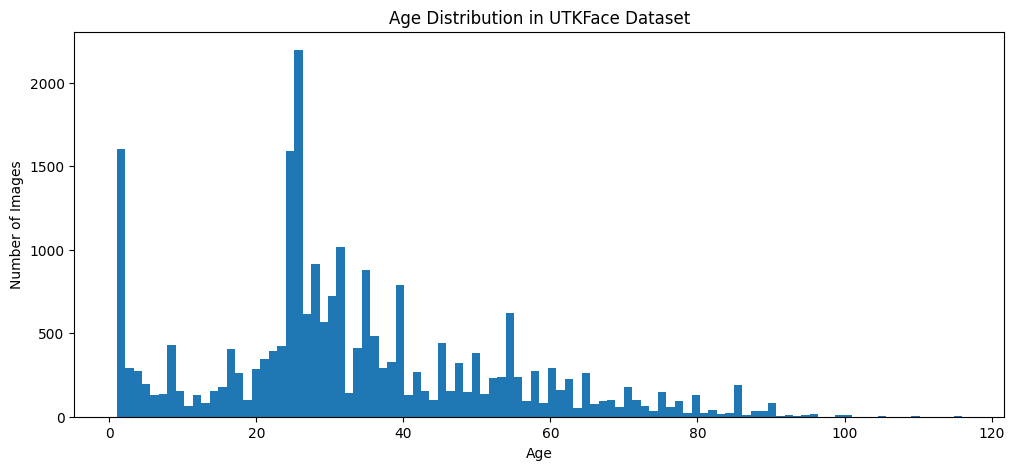

<Figure size 640x480 with 0 Axes>

In [218]:
plt.figure(figsize=(12,5))

plt.hist(
    age_df["age"],
    bins=100
)

plt.title("Age Distribution in UTKFace Dataset")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.show()
plt.savefig(f"{PROJECT_FIGURES}/age_distribution.pdf", bbox_inches="tight")

### Code: Define Age Groups

In [219]:
def age_to_class(age):

    if age <= 25:
        return "young"

    elif age <= 50:
        return "adult"

    else:
        return "old"

### Code: Create Age-Group Labels

In [220]:
age_df["class"] = age_df["age"].apply(age_to_class)

age_df.head()

,age,class
0,100,old
1,100,old
2,100,old
3,100,old
4,100,old


### Code: Examine Class Distribution

Expected output:

```
adult    11463
young     7637
old       4608
```

In [221]:
class_counts = age_df["class"].value_counts()

print(class_counts)

class
adult    11463
young     7637
old       4608
Name: count, dtype: int64


### Code: Calculate Class Percentages

In [222]:
class_percentages = (
    age_df["class"]
    .value_counts(normalize=True)
    * 100
)

print(class_percentages.round(2))

class
adult    48.35
young    32.21
old      19.44
Name: proportion, dtype: float64


# Step 3: Create the Metadata Table

## Description

In this step, we create a metadata table that contains:

- Image filename
- Age extracted from the filename
- Corresponding age-group label

This table will be used throughout the project and allows us to split the dataset without loading images into memory.

### Code

In [223]:
# Age grouping function
def age_to_class(age):
    if age <= 25:
        return "young"
    elif age <= 50:
        return "adult"
    else:
        return "old"

records = []

for file in os.listdir(dataset_path):
    try:
        age = int(file.split('_')[0])

        records.append({
            "filename": file,
            "age": age,
            "class": age_to_class(age)
        })

    except:
        continue

df = pd.DataFrame(records)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (23708, 3)


,filename,age,class
0,100_0_0_20170112213500903.jpg.chip.jpg,100,old
1,100_0_0_20170112215240346.jpg.chip.jpg,100,old
2,100_1_0_20170110183726390.jpg.chip.jpg,100,old
3,100_1_0_20170112213001988.jpg.chip.jpg,100,old
4,100_1_0_20170112213303693.jpg.chip.jpg,100,old


In [224]:
# Save metadata table
df.to_csv(f"{PROJECT_DATA}/metadata.csv", index=False)
print("Metadata saved.")

Metadata saved.


# Step 4: Verify Age Group Distribution

## Description

Before splitting the dataset, verify that the age groups were created correctly and inspect the class distribution.

### Code

class
adult    11463
young     7637
old       4608
Name: count, dtype: int64


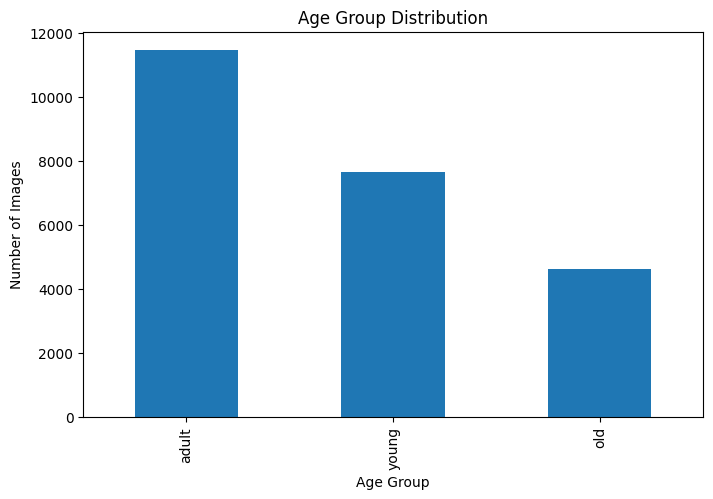

<Figure size 640x480 with 0 Axes>

In [225]:
import matplotlib.pyplot as plt

class_counts = df["class"].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Images")
plt.show()
plt.savefig(f"{PROJECT_FIGURES}/class_distribution.pdf", bbox_inches="tight")

# Step 5: Perform Stratified Train-Validation-Test Split

## Description

A stratified split preserves the proportion of each age group across all subsets.

Split ratios:

- Training: 70%
- Validation: 15%
- Testing: 15%

### Code

In [226]:
# Train = 70%, Temp = 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

# Validation = 15%, Test = 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (16595, 3)
Validation Shape: (3556, 3)
Test Shape: (3557, 3)


In [227]:
# Save dataset splits
train_df.to_csv(f"{PROJECT_DATA}/train_df.csv", index=False)
val_df.to_csv(f"{PROJECT_DATA}/val_df.csv", index=False)
test_df.to_csv(f"{PROJECT_DATA}/test_df.csv", index=False)
print("Train/Validation/Test splits saved.")

Train/Validation/Test splits saved.


# Step 6: Verify Class Distribution After Splitting

## Description

Confirm that the stratified split maintained class proportions.

### Code

In [228]:
print("Training Set")
print(train_df["class"].value_counts())

print("\nValidation Set")
print(val_df["class"].value_counts())

print("\nTest Set")
print(test_df["class"].value_counts())

Training Set
class
adult    8024
young    5346
old      3225
Name: count, dtype: int64

Validation Set
class
adult    1719
young    1145
old       692
Name: count, dtype: int64

Test Set
class
adult    1720
young    1146
old       691
Name: count, dtype: int64


### Code

In [229]:
print("Training Proportions")
print(train_df["class"].value_counts(normalize=True))

print("\nValidation Proportions")
print(val_df["class"].value_counts(normalize=True))

print("\nTest Proportions")
print(test_df["class"].value_counts(normalize=True))

Training Proportions
class
adult    0.483519
young    0.322145
old      0.194336
Name: proportion, dtype: float64

Validation Proportions
class
adult    0.483408
young    0.321991
old      0.194601
Name: proportion, dtype: float64

Test Proportions
class
adult    0.483554
young    0.322182
old      0.194265
Name: proportion, dtype: float64


# Step 7: Create Processed Dataset Folder Structure

## Description

Create the directory structure required for generator-based training.

Final structure:

```
UTKFace_Processed/

    train/
        young/
        adult/
        old/

    val/
        young/
        adult/
        old/

    test/
        young/
        adult/
        old/
```

### Code

In [230]:
base_dir = "../UTKFace_Processed"

splits = ["train", "val", "test"]
classes = ["young", "adult", "old"]

for split in splits:
    for cls in classes:
        os.makedirs(
            os.path.join(base_dir, split, cls),
            exist_ok=True
        )

print("Folder structure created successfully.")

Folder structure created successfully.


# Step 8: Copy Images Into Their Corresponding Folders

## Description

Move each image into the appropriate split and class folder according to the previously generated DataFrames.

### Code

In [231]:
base_dir = "../UTKFace_Processed"

# If the folder already exists, skip everything
if os.path.exists(base_dir):
    print("Folder structure already exists. Skipping folder creation and copying.")
else:
    print("Folder structure not found. Creating folders and copying images...")

    splits = ["train", "val", "test"]
    classes = ["young", "adult", "old"]

    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

    print("Folder structure created successfully.")

    def copy_images(dataframe, split_name):
        for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
            src = os.path.join(dataset_path, row["filename"])
            dst = os.path.join(base_dir, split_name, row["class"], row["filename"])
            shutil.copy(src, dst)

    copy_images(train_df, "train")
    copy_images(val_df, "val")
    copy_images(test_df, "test")

    print("Images copied successfully.")


Folder structure already exists. Skipping folder creation and copying.


# Step 9: Verify Folder Contents

## Description

Verify that images were copied correctly and class counts match the metadata.

### Code

In [232]:
for split in splits:

    print(f"\n{split.upper()}")

    for cls in classes:

        path = os.path.join(
            base_dir,
            split,
            cls
        )

        count = len(os.listdir(path))

        print(f"{cls}: {count}")


TRAIN
young: 5346
adult: 8024
old: 3225

VAL
young: 1145
adult: 1719
old: 692

TEST
young: 1146
adult: 1720
old: 691


### Cleanup Invalid Image Files

In [233]:
from pathlib import Path

valid_extensions = {'.jpg', '.jpeg', '.png'}
invalid_files = []

for root, _, files in os.walk(base_dir):
    for filename in files:
        path = Path(root) / filename
        if path.stat().st_size == 0 or path.suffix.lower() not in valid_extensions:
            invalid_files.append(str(path))
            try:
                path.unlink()
            except Exception as e:
                print(f"Could not remove invalid file {path}: {e}")

print("Invalid files removed:")
for path in invalid_files:
    print(path)
print("Total invalid files removed:", len(invalid_files))

Invalid files removed:
..\UTKFace_Processed\train\old\70_0_0_20170104185854046.jpg.chip.jpg
Total invalid files removed: 1


# Step 10: Create Image Generators

## Description

Use generators to load images in batches instead of loading the entire dataset into RAM.

Benefits:

- Lower memory consumption
- Faster training
- Better scalability
- Standard deep-learning workflow

### Code

In [234]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Remove invalid files before building the dataset
from pathlib import Path
valid_extensions = {'.jpg', '.jpeg', '.png'}
invalid_files = []

for root, _, files in os.walk(base_dir):
    for filename in files:
        path = Path(root) / filename
        if path.stat().st_size == 0 or path.suffix.lower() not in valid_extensions:
            invalid_files.append(str(path))
            try:
                path.unlink()
            except Exception as e:
                print(f"Could not remove invalid file {path}: {e}")

if invalid_files:
    print("Invalid files removed before generator creation:")
    for path in invalid_files:
        print(path)
    print("Total invalid files removed:", len(invalid_files))

# Data augmentation for training
train_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
    tf.keras.layers.RandomFlip("horizontal"),
])

print("Data generators configured.")

Data generators configured.


### Training Generator

In [235]:
train_generator = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Apply data augmentation to training set
train_generator = train_generator.map(
    lambda x, y: (train_data_augmentation(x, training=True), y)
)

Found 16594 files belonging to 3 classes.


### Validation Generator

In [ ]:
val_generator = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 3556 files belonging to 3 classes.


### Test Generator

In [237]:
test_generator = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 3557 files belonging to 3 classes.


# Step 11: Verify Generator Output

## Description

Inspect a batch to ensure that images and labels are being loaded correctly.

### Code

In [238]:
images, labels = next(iter(train_generator))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 3)


In [ ]:
print(os.listdir("../"))

['.git', 'dataset', 'evaluation_results', 'figures', 'logs', 'notebooks', 'project_data', 'README.md', 'reports', 'saved_models', 'UTKFace_Processed']


# Additional Project Utilities

These cells improve reproducibility and project organization.

### Create Global Configuration

In [240]:
# Global project configuration
RANDOM_SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

PROJECT_ROOT = "../"
FIGURES_DIR = f"{PROJECT_ROOT}/figures"
DATA_DIR = f"{PROJECT_ROOT}/project_data"
MODELS_DIR = f"{PROJECT_ROOT}/saved_models"
RESULTS_DIR = f"{PROJECT_ROOT}/evaluation_results"
LOGS_DIR = f"{PROJECT_ROOT}/logs"

print("Configuration loaded.")

Configuration loaded.


### Save Dataset Statistics

In [241]:
dataset_stats = pd.DataFrame({
    'Metric':['Total Images','Young','Adult','Old'],
    'Value':[len(df),
             (df['class']=='young').sum(),
             (df['class']=='adult').sum(),
             (df['class']=='old').sum()]
})

dataset_stats.to_csv(
    f"{DATA_DIR}/dataset_statistics.csv",
    index=False
)

dataset_stats

,Metric,Value
0,Total Images,23708
1,Young,7637
2,Adult,11463
3,Old,4608


### Save Sample Faces Figure

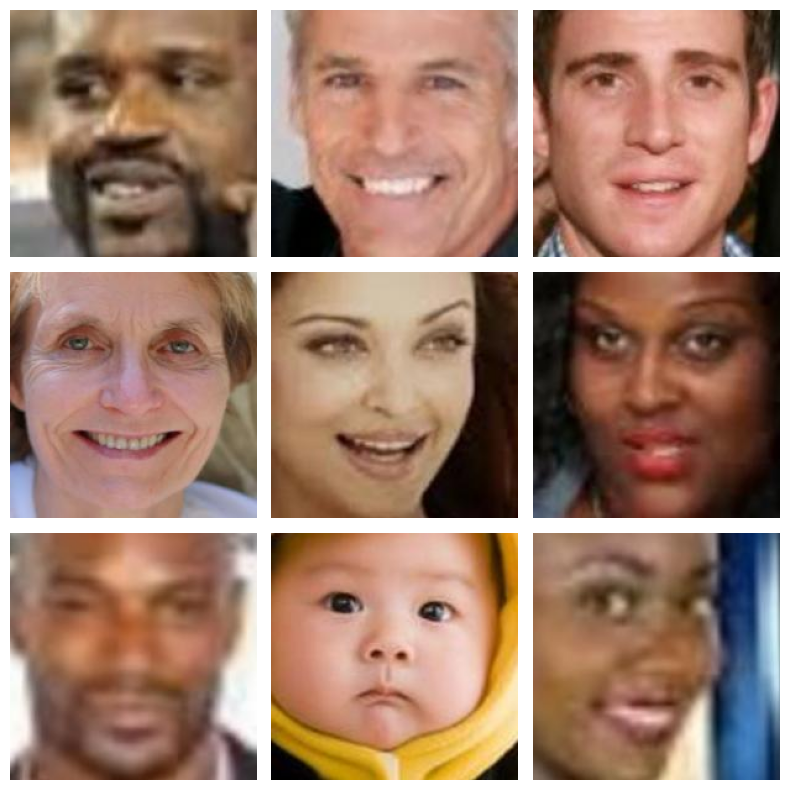

In [242]:
sample_files = random.sample(list(df['filename']), 9)

fig, axes = plt.subplots(3,3, figsize=(8,8))

for ax, file in zip(axes.flatten(), sample_files):
    img = Image.open(os.path.join(dataset_path, file))
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/sample_faces.pdf",
    bbox_inches='tight'
)

plt.show()

### Verify Project Outputs

In [243]:
folders = [
    FIGURES_DIR,
    DATA_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    LOGS_DIR
]

for folder in folders:
    print(f"\n{folder}")
    print(os.listdir(folder))


..//figures
['age_distribution.pdf', 'class_distribution.pdf', 'sample_faces.pdf']

..//project_data
['class_weights.csv', 'cnn_architecture.txt', 'dataset_statistics.csv', 'metadata.csv', 'test_df.csv', 'train_df.csv', 'val_df.csv']

..//saved_models
[]

..//evaluation_results
[]

..//logs
['cnn_training_log.csv']


# Step 12: Build the Baseline CNN Model

## Description

The first model should be a custom CNN built from scratch.

Why?

* Serves as a baseline.
* Provides a reference point for comparison.
* Helps demonstrate the benefit of transfer learning later.
* Required in most Pattern Recognition and Deep Learning projects.

The architecture does not need to be complex.

## Step 12.1: Import Deep Learning Libraries

In [244]:
from keras.models import Sequential
from keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Step 12.2: Compute Class Weights

### Description

Your classes are imbalanced:

| Class |  Count |
| ----- | -----: |
| Adult | 11,463 |
| Young |  7,637 |
| Old   |  4,608 |

Class weights help prevent the model from favoring the Adult class.

In [245]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["class"]),
    y=train_df["class"]
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

pd.DataFrame(
    class_weights.items(),
    columns=["class_index", "weight"]
).to_csv(
    "../project_data/class_weights.csv",
    index=False
)

{0: np.float64(0.6893901628447989), 1: np.float64(1.7152454780361757), 2: np.float64(1.0347300162114976)}


## Step 12.3: Build CNN Architecture

### Description

Architecture:

```text
Input (224x224x3)

Conv -> BN -> Pool

Conv -> BN -> Pool

Conv -> BN -> Pool

Flatten

Dense(256)

Dropout

Dense(3)
```

In [246]:
cnn_model = Sequential([

    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

## Step 12.4: Compile Model

### Description

Since this is a multi-class classification problem:

* Loss = Categorical Crossentropy
* Optimizer = Adam
* Metric = Accuracy

In [247]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 12.5: Display Model Summary

In [248]:
cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,315 (73.99 MB)

 Trainable params: 19,396,355 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 12.6: Save Architecture Summary

In [249]:
with open(
    "../project_data/cnn_architecture.txt",
    "w",
    encoding='utf-8'
) as f:

    cnn_model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

# Step 13: Train the Baseline CNN

Before training, we'll create professional callbacks:

### Early Stopping

In [250]:
from keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

### Callbacks

In [251]:
cnn_callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        filepath='../saved_models/cnn_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(
        filename='../logs/cnn_training_log.csv'
    )
]

### Then train

In [252]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=cnn_callbacks
)

Epoch 1/20


519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3768 - loss: 1.9884
Epoch 1: val_accuracy improved from None to 0.46569, saving model to ../saved_models/cnn_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 959s 2s/step - accuracy: 0.3832 - loss: 1.5763 - val_accuracy: 0.4657 - val_loss: 1.0334 - learning_rate: 1.0000e-04
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4163 - loss: 1.1138
Epoch 2: val_accuracy did not improve from 0.46569
519/519 ━━━━━━━━━━━━━━━━━━━━ 1071s 2s/step - accuracy: 0.4314 - loss: 1.0809 - val_accuracy: 0.4109 - val_loss: 1.0813 - learning_rate: 1.0000e-04
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4641 - loss: 1.0453
Epoch 3: val_accuracy improved from 0.46569 to 0.53965, saving model to ../saved_models/cnn_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 1335s 3s/step - accuracy: 0.4749 - loss: 1.0371 - val_accuracy: 0.5397 - val_loss: 0.9611 - learning_rate: 1.0000e-04
Epoch 4/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy:

# 17. Accuracy and Loss Curves

Training and validation accuracy/loss curves are plotted to evaluate model learning behavior during training. These curves help identify overfitting, underfitting, and convergence performance.

## 17.1 Plot Accuracy Curve

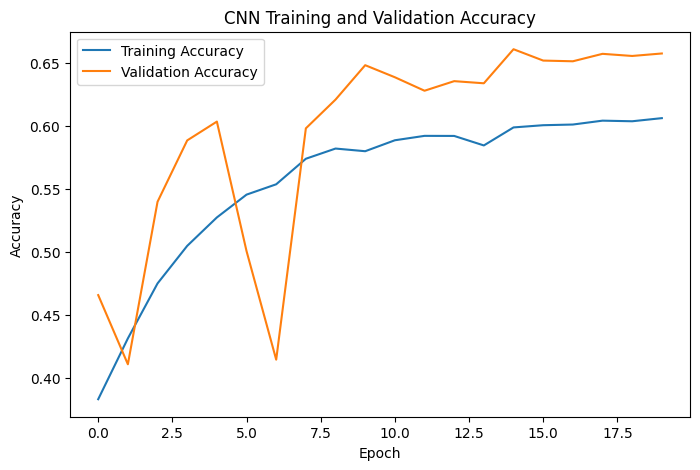

In [253]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(f"{PROJECT_FIGURES}/cnn-training-and-validation_accuracy.pdf", bbox_inches="tight")
plt.show()

## 17.2 Plot Loss Curve

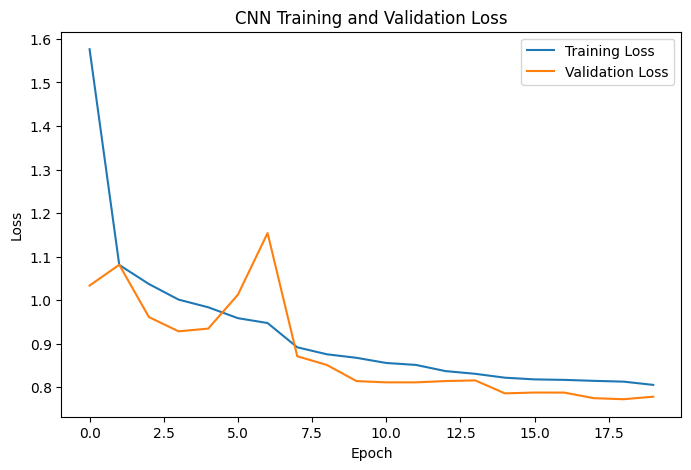

In [254]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(f"{PROJECT_FIGURES}/cnn-training-and-validation_loss.pdf", bbox_inches="tight")
plt.show()

## 17.3 Evaluate CNN on Validation Set

# Step 14: MobileNetV2 — Transfer Learning Model

## Description

MobileNetV2 is a lightweight, efficient deep neural network architecture designed for mobile and embedded vision applications. It introduces two key innovations:

- **Inverted residuals**: Expand features in a bottleneck layer, apply depthwise convolution, then project back to a smaller dimension.
- **Linear bottlenecks**: Prevent information loss when projecting back to a lower dimension by removing the non-linearity at the output of each bottleneck.

### Why MobileNetV2 for this task?

| Property | Value |
| --- | --- |
| Pre-trained on | ImageNet (1.2M images, 1000 classes) |
| Input size | 224 × 224 × 3 |
| Parameters | ~3.4 M (frozen base) |
| Strengths | Fast inference, small memory footprint, good accuracy |

### Transfer Learning Strategy

The base MobileNetV2 is loaded with **ImageNet weights** and initially **frozen**. A custom classification head is added on top. Training is done in two phases:

1. **Phase 1 — Feature Extraction**: Only the custom head is trained (base frozen).
2. **Phase 2 — Fine-Tuning**: The top layers of the base are unfrozen and trained with a very low learning rate.

This approach leverages pre-trained feature representations while adapting the model to our 3-class age-group problem.

## Step 14.1: Import Libraries for MobileNetV2

In [255]:
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from keras.optimizers import Adam
from keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("TensorFlow Version:", tf.__version__)
print("All MobileNetV2 libraries imported successfully.")

TensorFlow Version: 2.21.0
All MobileNetV2 libraries imported successfully.


## Step 14.2: Build MobileNetV2 Architecture

### Phase 1 — Feature Extraction

The base MobileNetV2 is loaded with ImageNet weights and frozen. A classification head consisting of Global Average Pooling, Batch Normalization, Dense(256), Dropout, and a final Dense(3, softmax) layer is appended.

In [256]:
# Load MobileNetV2 base (frozen)
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,         # Remove original classifier
    input_shape=(224, 224, 3)
)
mobilenet_base.trainable = False  # Freeze all base layers

# Build classification head
inputs = Input(shape=(224, 224, 3), name='input_layer')
x = mobilenet_base(inputs, training=False)
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = BatchNormalization(name='bn_head')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.4, name='dropout_04')(x)
outputs = Dense(3, activation='softmax', name='output_softmax')(x)

mobilenet_model = Model(inputs, outputs, name='MobileNetV2_AgeGroup')

print("MobileNetV2 model built successfully.")
print(f"Base layers frozen: {len(mobilenet_base.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step
MobileNetV2 model built successfully.
Base layers frozen: 154


## Step 14.3: Display Model Summary

In [257]:
mobilenet_model.summary()

Model: "MobileNetV2_AgeGroup"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_04 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

### Save Architecture Summary to File

In [259]:
arch_path = f"{PROJECT_DATA}/mobilenetv2_architecture.txt"

with open(arch_path, "w") as f:
    arch_path = f"{PROJECT_DATA}/mobilenetv2_architecture.txt"

    with open(arch_path, "w", encoding="utf-8") as f:
        mobilenet_model.summary(print_fn=lambda x: f.write(x + "\n"))

    print(f"Architecture summary saved to: {arch_path}")

print(f"Architecture summary saved to: {arch_path}")

Architecture summary saved to: ..//project_data/mobilenetv2_architecture.txt
Architecture summary saved to: ..//project_data/mobilenetv2_architecture.txt


## Step 14.4: Compile and Train — Phase 1 (Feature Extraction)

The model is compiled with a relatively high learning rate for the head layers. Early stopping and learning rate reduction are applied.

In [260]:
import time

# Compile — Phase 1
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — Phase 1
mobilenet_callbacks_p1 = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f'{SAVED_MODELS}/mobilenetv2_phase1_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(f'{LOGS_DIR}/mobilenetv2_phase1_log.csv')
]

print("Phase 1 — Feature Extraction Training")
print(f"Trainable parameters: {mobilenet_model.count_params():,}")

start_time_p1 = time.time()

history_mobilenet_p1 = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks_p1
)

p1_time = time.time() - start_time_p1
print(f"\nPhase 1 training completed in {p1_time:.1f} seconds.")

Phase 1 — Feature Extraction Training
Trainable parameters: 2,591,811
Epoch 1/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.4817 - loss: 1.2801
Epoch 1: val_accuracy improved from None to 0.59674, saving model to ..//saved_models/mobilenetv2_phase1_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 458s 877ms/step - accuracy: 0.4993 - loss: 1.1211 - val_accuracy: 0.5967 - val_loss: 0.8502 - learning_rate: 0.0010
Epoch 2/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.5379 - loss: 0.9048
Epoch 2: val_accuracy did not improve from 0.59674
519/519 ━━━━━━━━━━━━━━━━━━━━ 457s 881ms/step - accuracy: 0.5319 - loss: 0.9081 - val_accuracy: 0.5515 - val_loss: 0.8823 - learning_rate: 0.0010
Epoch 3/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.5406 - loss: 0.8815
Epoch 3: val_accuracy did not improve from 0.59674
519/519 ━━━━━━━━━━━━━━━━━━━━ 465s 810ms/step - accuracy: 0.5381 - loss: 0.8915 - val_accuracy: 0.5889 - val_loss: 0.8603 - learning_rate: 0.0010
Epoch 4/15
51

## Step 14.5: Fine-Tuning — Unfreeze Top Layers (Phase 2)

After the head has converged, the top 30 layers of the MobileNetV2 base are unfrozen and retrained with a very low learning rate to adapt higher-level features to the age-group task.

In [263]:
# Unfreeze the top 30 layers of the base
mobilenet_base.trainable = True

fine_tune_from = len(mobilenet_base.layers) - 30

for layer in mobilenet_base.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Total base layers        : {len(mobilenet_base.layers)}")
print(f"Fine-tuning from layer   : {fine_tune_from}")
print(f"Trainable layers unfrozen: {len(mobilenet_base.layers) - fine_tune_from}")

# Recompile with a very low learning rate
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — Phase 2
mobilenet_callbacks_p2 = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f'{SAVED_MODELS}/mobilenetv2_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(f'{LOGS_DIR}/mobilenetv2_phase2_log.csv')
]

print("\nPhase 2 — Fine-Tuning Training")

start_time_p2 = time.time()

history_mobilenet_p2 = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks_p2
)

p2_time = time.time() - start_time_p2
print(f"\nPhase 2 training completed in {p2_time:.1f} seconds.")

Total base layers        : 154
Fine-tuning from layer   : 124
Trainable layers unfrozen: 30

Phase 2 — Fine-Tuning Training
Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.6051 - loss: 0.7912
Epoch 1: val_accuracy improved from None to 0.64595, saving model to ..//saved_models/mobilenetv2_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 510s 973ms/step - accuracy: 0.6008 - loss: 0.7965 - val_accuracy: 0.6460 - val_loss: 0.7614 - learning_rate: 1.0000e-05
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.5988 - loss: 0.7892
Epoch 2: val_accuracy did not improve from 0.64595
519/519 ━━━━━━━━━━━━━━━━━━━━ 424s 816ms/step - accuracy: 0.5988 - loss: 0.7946 - val_accuracy: 0.6350 - val_loss: 0.7819 - learning_rate: 1.0000e-05
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.6092 - loss: 0.7741
Epoch 3: val_accuracy improved from 0.64595 to 0.64679, saving model to ..//saved_models/mobilenetv2_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 566s 1s/step 

## Step 14.6: Merge Phase 1 and Phase 2 Training Histories

In [264]:
def merge_histories(h1, h2):
    """Concatenate two Keras history objects for combined plotting."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history_mobilenet = merge_histories(history_mobilenet_p1, history_mobilenet_p2)

print("Merged history keys:", list(history_mobilenet.keys()))
print(f"Total epochs trained : {len(history_mobilenet['accuracy'])}")

Merged history keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
Total epochs trained : 23


## Step 14.7: Plot Training and Validation Accuracy

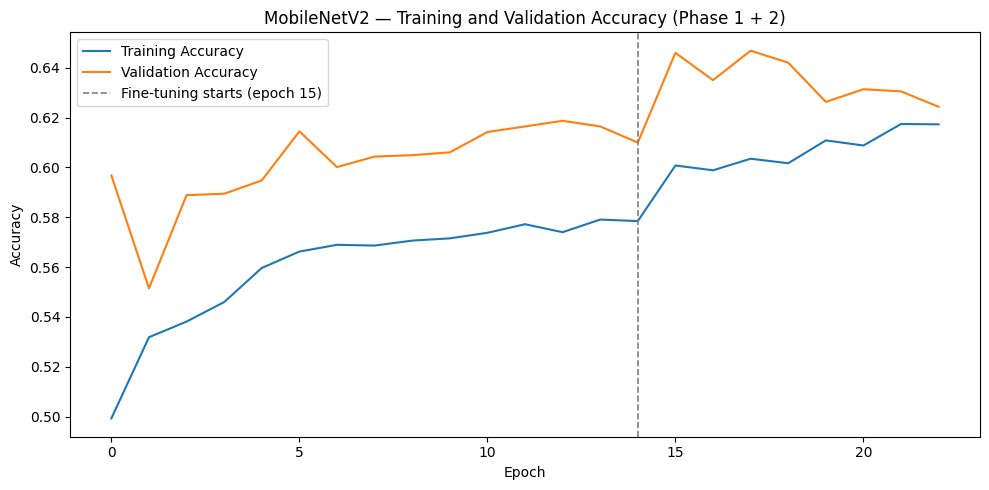

Accuracy plot saved.


In [265]:
p1_epochs = len(history_mobilenet_p1.history['accuracy'])
total_epochs = len(history_mobilenet['accuracy'])

plt.figure(figsize=(10, 5))

plt.plot(history_mobilenet['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet['val_accuracy'], label='Validation Accuracy')

# Mark the boundary between Phase 1 and Phase 2
plt.axvline(
    x=p1_epochs - 1,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label=f'Fine-tuning starts (epoch {p1_epochs})'
)

plt.title("MobileNetV2 — Training and Validation Accuracy (Phase 1 + 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/mobilenetv2_accuracy.pdf",
    bbox_inches="tight"
)
plt.show()
print("Accuracy plot saved.")

## Step 14.8: Plot Training and Validation Loss

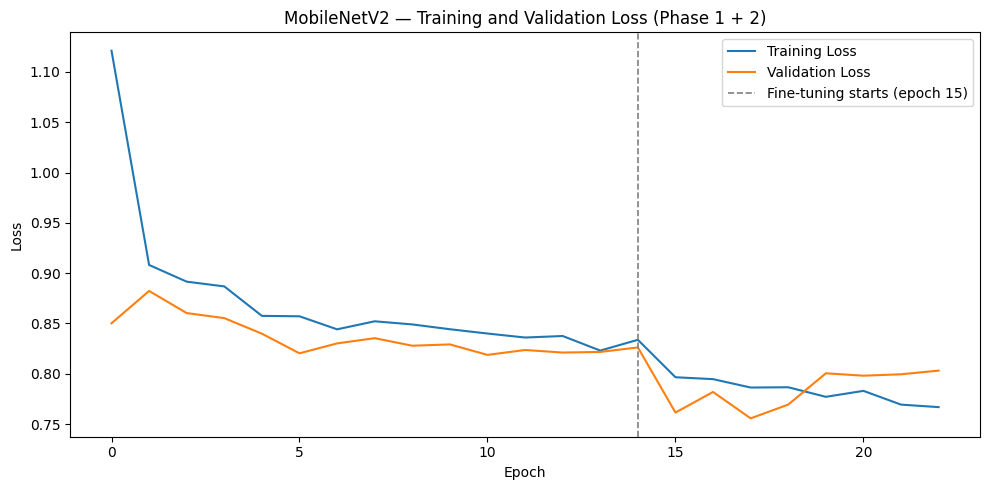

Loss plot saved.


In [266]:
plt.figure(figsize=(10, 5))

plt.plot(history_mobilenet['loss'], label='Training Loss')
plt.plot(history_mobilenet['val_loss'], label='Validation Loss')

plt.axvline(
    x=p1_epochs - 1,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label=f'Fine-tuning starts (epoch {p1_epochs})'
)

plt.title("MobileNetV2 — Training and Validation Loss (Phase 1 + 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/mobilenetv2_loss.pdf",
    bbox_inches="tight"
)
plt.show()
print("Loss plot saved.")

## Step 14.9: Evaluate MobileNetV2 on Validation Set

The test set is preserved strictly for the final benchmarking step after all models are trained. Evaluation here uses the **validation set** only.

In [ ]:
# Class index mapping from generator
class_indices = val_generator.class_indices          # e.g. {'adult':0,'old':1,'young':2}
idx_to_class  = {v: k for k, v in class_indices.items()}
class_names   = [idx_to_class[i] for i in range(3)]

print("Class index mapping:", class_indices)
print("Class names order  :", class_names)

AttributeError: '_PrefetchDataset' object has no attribute 'class_indices'